<a href="https://colab.research.google.com/github/JonathanDLCH/Crypto_DataAnalysis/blob/main/1_1Request_function_client.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 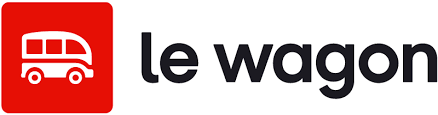

# Request -> Function -> Client

---

En esta seccion exploraremos como evolucionar nuestro codigo de simples solicitudes HTTP hacia codigo mas organizado y reutilizable. Veremos la progresion natural: primero hacemos una solicitud directa, luego la encapsulamos en una funcion, y finalmente agrupamos funciones relacionadas en una clase cliente.

## Objetivos de Aprendizaje

- Construir codigo reutilizable a partir de solicitudes HTTP
- Entender los diferentes niveles de abstraccion en programacion
- Crear funciones que encapsulen logica repetitiva
- Disenar una clase cliente para interactuar con APIs

---

## Setup

In [ ]:
import requests
import pandas as pd

print("Libraries imported successfully!")

Libraries imported successfully!


---

## 1. Request

Este es un repaso rapido de como hacer solicitudes HTTP directas a la API de Binance. Ya vimos esto en la sesion anterior, pero lo necesitamos como punto de partida.

In [ ]:
# Binance.US API endpoint for klines (candlestick data)
# Endpoint: https://api.binance.us/api/v3/klines
# Parameters: symbol, interval, limit

# Your code here
url="https://api.binance.us/api/v3/klines"
params = {
    "symbol": "BTCUSD",
    "interval": "1d",
    "limit": 30
}
req = requests.get(url, params)
data = req.json()
len(data[0])


12

**Output esperado:**
```
Total candles received: 30

First candle (raw):
[1735689600000, '93508.00000000', '94500.00000000', '91200.00000000', '94300.00000000', '11234.56780000', ...]
```

Cada vela es una lista con 12 valores: timestamp, open, high, low, close, volume, y otros campos adicionales.

In [ ]:
# Convert raw data to DataFrame
# Columns from Binance docs: open_time, open, high, low, close, volume,
#   close_time, quote_asset_volume, number_of_trades,
#   taker_buy_base_volume, taker_buy_quote_volume, ignore

# Steps:
# 1. Create DataFrame with column names
# 2. Convert timestamps (open_time, close_time) to datetime
# 3. Convert price columns to float
# 4. Keep only relevant columns: open_time, open, high, low, close, volume

# Your code
columns = [
    "open_time", "open", "high", "low", "close", "volume",
    "close_time", "quote_asset_volume", "number_of_trades",
    "taker_buy_base_volume", "taker_buy_quote_volume", "ignore"
]
df_coin = pd.DataFrame(data, columns=columns)
df_coin['open_time'] = pd.to_datetime(df_coin['open_time'], unit='ms')
df_coin['close_time'] = pd.to_datetime(df_coin['close_time'], unit='ms')
# df_coin.dtypes
price_cols = ["open", "high", "low", "close", "volume"]
df_coin[price_cols] = df_coin[price_cols].astype(float)
df_coin.dtypes

df_coin = df_coin[["open_time", "open", "high", "low", "close", "volume"]]
df_coin.head()

,open_time,open,high,low,close,volume
0,2026-01-25,89137.06,89176.01,86007.17,86622.05,23.42658
1,2026-01-26,86622.05,88780.70,86450.00,88280.05,18.48380
2,2026-01-27,88303.64,89410.04,87187.05,89133.05,20.31722
3,2026-01-28,89133.05,90469.40,88744.31,89153.05,19.59118
4,2026-01-29,89148.66,89148.66,83272.01,84570.00,31.95113


**Output esperado (df.head()):**

| | open_time | open | high | low | close | volume |
|---|-----------|------|------|-----|-------|--------|
| 0 | 2025-01-01 | 93508.0 | 94500.0 | 91200.0 | 94300.0 | 11234.5 |
| 1 | 2025-01-02 | 94300.0 | 96100.0 | 93800.0 | 95200.0 | 9876.3 |
| ... | ... | ... | ... | ... | ... | ... |

Documentacion: [Binance.US API - Klines](https://docs.binance.us/#get-candlestick-data)

---

## 2. Function

El codigo anterior funciona, pero tiene un problema: si necesitamos obtener datos de 10 criptomonedas diferentes, tendriamos que copiar y pegar el mismo codigo 10 veces, cambiando solo el simbolo. Esto viola el principio DRY (Don't Repeat Yourself).

### Mini repaso de funciones

Una funcion es un bloque de codigo reutilizable que recibe parametros y retorna un resultado. La sintaxis basica es:

```python
def nombre_funcion(parametro1, parametro2):
    # codigo
    return resultado
```

Documentacion: [Python Functions](https://docs.python.org/3/tutorial/controlflow.html#defining-functions)

### Ejercicio 1: `get_klines`

Crea una funcion que encapsule la logica de obtener datos de velas (klines) de Binance.

In [ ]:
def get_klines(symbol, interval, limit):
    """
    Get candlestick (klines) data from Binance API.

    Args:
        symbol: Trading pair (e.g., 'BTCUSD', 'ETHUSD')
        interval: Candle interval (e.g., '1d', '1h', '15m')
        limit: Number of candles to retrieve

    Returns:
        DataFrame with columns: open_time, open, high, low, close, volume
    """
    # Your code
    url="https://api.binance.us/api/v3/klines"
    params = {
        "symbol": symbol,
        "interval": interval,
        "limit": limit
    }
    columns = [
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_asset_volume", "number_of_trades",
        "taker_buy_base_volume", "taker_buy_quote_volume", "ignore"
    ]
    req_columns=["open_time", "open", "high", "low", "close", "volume"]

    req = requests.get(url, params)
    data = req.json()
    df = pd.DataFrame(data, columns=columns)
    df = df[req_columns]
    df['open_time'] = pd.to_datetime(df['open_time'], unit='ms')
    price_cols = ["open", "high", "low", "close", "volume"]
    df_coin[price_cols] = df_coin[price_cols].astype(float)
    return df

In [ ]:
# Test your function
df_btc = get_klines("BTCUSD", "1d", 30)
df_btc.head()

,open_time,open,high,low,close,volume
0,2026-01-25,89137.06000000,89176.01000000,86007.17000000,86622.05000000,23.42658000
1,2026-01-26,86622.05000000,88780.70000000,86450.00000000,88280.05000000,18.48380000
2,2026-01-27,88303.64000000,89410.04000000,87187.05000000,89133.05000000,20.31722000
3,2026-01-28,89133.05000000,90469.40000000,88744.31000000,89153.05000000,19.59118000
4,2026-01-29,89148.66000000,89148.66000000,83272.01000000,84570.00000000,31.95113000


In [ ]:
# Now we can easily get data for multiple symbols
df_eth = get_klines("ETHUSD", "1d", 30)
df_eth.head()

,open_time,open,high,low,close,volume
0,2026-01-25,2951.74000000,2955.55000000,2785.67000000,2816.05000000,1037.13610000
1,2026-01-26,2815.00000000,2948.53000000,2812.32000000,2928.16000000,1334.43850000
2,2026-01-27,2924.96000000,3030.02000000,2900.00000000,3021.37000000,857.96030000
3,2026-01-28,3021.72000000,3039.53000000,2978.74000000,3004.28000000,946.03140000
4,2026-01-29,3006.56000000,3007.25000000,2751.00000000,2823.60000000,1155.32380000


### Ejercicio 2: `get_price`

Crea una funcion que obtenga el precio actual de un simbolo usando el endpoint `/ticker/price` de Binance.

In [ ]:
def get_price(symbol):
    """
    Get current price for a trading pair from Binance API.

    Args:
        symbol: Trading pair (e.g., 'BTCUSD', 'ETHUSD')

    Returns:
        Current price as float
    """
    # Hint: Use endpoint https://api.binance.us/api/v3/ticker/price
    # Your code here
    url="https://api.binance.us/api/v3/ticker/price"
    params = {
        "symbol": symbol
    }

    req = requests.get(url, params)
    data = req.json()
    data['price'] = float(data['price'])
    return data['price']

In [ ]:
# Test your function
btc_price = get_price("BTCUSD")
eth_price = get_price("ETHUSD")

print(f"BTC price: ${btc_price:,.2f}")
print(f"ETH price: ${eth_price:,.2f}")

BTC price: $64,781.97
ETH price: $1,863.26


---

## 3. Client

Nuestras funciones funcionan bien, pero notaras que comparten caracteristicas comunes: usan la misma URL base (`https://api.binance.us/api/v3`), interactuan con la misma API, y realizan operaciones relacionadas. Cuando tenemos funciones relacionadas que comparten estado o configuracion, es buena idea agruparlas en una **clase**.

### Mini introduccion a clases

Una **clase** es como un plano o plantilla para crear objetos. Nos permite agrupar datos (atributos) y funciones (metodos) relacionados.

```python
class Calculator:
    def __init__(self, initial_value):
        self.value = initial_value
    
    def add(self, x):
        self.value = self.value + x
        return self.value

# Usage
calc = Calculator(10)
calc.add(5)  # Returns 15
```

- `class`: Palabra clave para definir una clase
- `__init__`: Metodo especial que se ejecuta al crear un objeto (constructor)
- `self`: Referencia al objeto actual, permite acceder a sus atributos y metodos

Documentacion: [Python Classes](https://docs.python.org/3/tutorial/classes.html)

### Ejercicio: `CryptoClient`

Crea una clase cliente que agrupe las funciones que creamos anteriormente.

In [ ]:
class CryptoClient:
    """
    Client for interacting with Binance.US API.
    """

    def __init__(self):
        """
        Initialize the client with base URL.
        """
        # Hint: Store the base URL as an attribute (self.base_url)
        # Your code here
        self.base_url = "https://api.binance.us/api/v3/"

    def get_klines(self, symbol, interval, limit):
        """
        Get candlestick (klines) data.

        Args:
            symbol: Trading pair (e.g., 'BTCUSD')
            interval: Candle interval (e.g., '1d', '1h')
            limit: Number of candles to retrieve

        Returns:
            DataFrame with OHLCV data
        """
        # Hint: Use self.base_url to build the full URL
        params = {
            "symbol": symbol,
            "interval": interval,
            "limit": limit
        }
        columns = [
            "open_time", "open", "high", "low", "close", "volume",
            "close_time", "quote_asset_volume", "number_of_trades",
            "taker_buy_base_volume", "taker_buy_quote_volume", "ignore"
        ]
        req_columns=["open_time", "open", "high", "low", "close", "volume"]
        req = requests.get(self.base_url+"klines", params)
        data = req.json()

        df = pd.DataFrame(data, columns=columns)
        df = df[req_columns]
        df['open_time'] = pd.to_datetime(df['open_time'], unit='ms')
        price_cols = ["open", "high", "low", "close", "volume"]
        df_coin[price_cols] = df_coin[price_cols].astype(float)
        return df


    def get_price(self, symbol):
        """
        Get current price for a trading pair.

        Args:
            symbol: Trading pair (e.g., 'BTCUSD')

        Returns:
            Current price as float
        """
        # Hint: Use self.base_url to build the full URL
        params = {
            "symbol": symbol
        }

        req = requests.get(self.base_url+"ticker/price", params)
        data = req.json()
        data['price'] = float(data['price'])
        return data['price']

In [ ]:
# Create client instance
client = CryptoClient()

# Test get_price
btc_price = client.get_price("BTCUSD")
print(f"BTC price: ${btc_price:,.2f}")

BTC price: $64,750.23


In [ ]:
# Test get_klines
df = client.get_klines("BTCUSD", "1d", 30)
df.head()

,open_time,open,high,low,close,volume
0,2026-01-25,89137.06000000,89176.01000000,86007.17000000,86622.05000000,23.42658000
1,2026-01-26,86622.05000000,88780.70000000,86450.00000000,88280.05000000,18.48380000
2,2026-01-27,88303.64000000,89410.04000000,87187.05000000,89133.05000000,20.31722000
3,2026-01-28,89133.05000000,90469.40000000,88744.31000000,89153.05000000,19.59118000
4,2026-01-29,89148.66000000,89148.66000000,83272.01000000,84570.00000000,31.95113000


---

## Cierre

En esta seccion recorrimos la progresion natural del codigo: desde solicitudes HTTP directas, pasando por funciones reutilizables, hasta una clase cliente organizada. Este patron es muy comun en el desarrollo de software.

De hecho, la libreria `pycoingecko` que usamos en la sesion anterior sigue exactamente este patron. Cuando escribimos `cg = CoinGeckoAPI()`, estamos creando una instancia de un cliente, igual que nuestro `CryptoClient`.